# P01 (basic) — Vorwaertskinematik, Arbeitsraum und die Jacobi-Matrix

**Modul 21 — Robotics 1**

Die erste Frage jedes Roboters lautet: **„Wo ist meine Hand?"** Die Antwort ist die
**Vorwaertskinematik** — ein Produkt homogener Transformationen entlang der Gelenkkette
(direkt auf Modul 19 aufbauend). Ihre **Ableitung**, die **Jacobi-Matrix**, beantwortet die
Folgefrage: *Wie bewegt sich die Hand, wenn ich die Gelenke drehe?* — und verraet, wo der Arm
**singulaer** wird.

### Ziel
Nach diesem Projekt kannst du …
- die allgemeine **DH-Transformationsmatrix** aufstellen (Kap. 4 des Skripts),
- die **kinematische Kette** als Matrixprodukt auswerten und gegen die geschlossene Formel pruefen,
- den **Arbeitsraum** eines Arms durch Sampling sichtbar machen,
- die **Jacobi-Matrix** analytisch aufstellen, numerisch verifizieren und ihre
  **Singularitaeten** ($\det\mathbf J = l_1 l_2 \sin q_2$) finden und interpretieren.

### Format
Jupyter-Notebook — Kinematik lebt vom Zusammenspiel aus Formel, Zahl und Zeichnung.

### Vorwissen
Homogene 4x4-Transformationen (**Modul 19**), Kap. 3-5 des Modul-21-Skripts, partielle Ableitungen.

### Aufgaben
Das meiste ist vorgegeben; an den `# TODO`-Stellen baust du die Kernbausteine. **Dies ist die vollstaendige Loesung.**


## Setup
Nur `numpy` und `matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)


## Teil A — Die DH-Transformationsmatrix

Die Denavit-Hartenberg-Konvention beschreibt den Uebergang von Frame $i-1$ zu Frame $i$ mit
**vier** Parametern $(\theta, d, a, \alpha)$ als
$\mathrm{Rot}_z(\theta)\,\mathrm{Trans}_z(d)\,\mathrm{Trans}_x(a)\,\mathrm{Rot}_x(\alpha)$:

$$^{i-1}\mathbf T_i=\begin{pmatrix}
\cos\theta & -\sin\theta\cos\alpha & \sin\theta\sin\alpha & a\cos\theta\\
\sin\theta & \cos\theta\cos\alpha & -\cos\theta\sin\alpha & a\sin\theta\\
0 & \sin\alpha & \cos\alpha & d\\
0&0&0&1\end{pmatrix}$$

**Deine Aufgabe:** Baue diese Matrix. (Tipp: erst die vier Einzelmatrizen, dann multiplizieren —
oder die ausmultiplizierte Form direkt eintragen. Beides ist gueltig.)

In [2]:
def dh_matrix(theta, d, a, alpha):
    # 4x4 DH-Transformationsmatrix
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    T = np.array([
        [ct, -st*ca,  st*sa, a*ct],
        [st,  ct*ca, -ct*sa, a*st],
        [0.0,    sa,     ca,    d],
        [0.0,   0.0,    0.0,  1.0]])
    return T

# Selbstcheck: theta=0,d=0,a=1,alpha=0 -> reine Verschiebung um 1 entlang x
print(dh_matrix(0.0, 0.0, 1.0, 0.0))
# Selbstcheck: 90 Grad um z, keine Verschiebung
print(dh_matrix(np.pi/2, 0.0, 0.0, 0.0).round(6))


[[ 1. -0.  0.  1.]
 [ 0.  1. -0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]
[[ 0. -1.  0.  0.]
 [ 1.  0. -0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]


**Erwartung.** Die erste Matrix ist die Identitaet mit einer 1 in der Translationsspalte $x$
(reine Verschiebung um 1 entlang $x$). Die zweite ist die 90-Grad-Rotation um $z$
(erste Spalte $(0,1,0)$, zweite $(-1,0,0)$).

## Teil B — Die kinematische Kette (Vorwaertskinematik)

Fuer einen **planaren** Arm mit Gliedlaengen $l_1,\dots,l_n$ und Drehgelenken gilt
$d_i=0$, $\alpha_i=0$, $a_i=l_i$, $\theta_i=q_i$. Die Pose des Endeffektors ist das
**Produkt der Kette**:

$$^{0}\mathbf T_n(\mathbf q) = {}^{0}\mathbf T_1(q_1)\,{}^{1}\mathbf T_2(q_2)\cdots{}^{n-1}\mathbf T_n(q_n)$$

**Deine Aufgabe:** Multipliziere die Kette auf und sammle dabei die **Gelenkpositionen**
(fuer die Zeichnung). Danach pruefen wir gegen die geschlossene Formel
$x=l_1\cos q_1 + l_2\cos(q_1{+}q_2)$, $y=l_1\sin q_1+l_2\sin(q_1{+}q_2)$.

In [3]:
def fk_joints(q, lengths):
    # Gibt die (n+1, 2) Gelenkpositionen zurueck: Basis (0,0) + jedes Gelenk + Endeffektor
    T = np.eye(4)
    pts = [np.zeros(2)]
    for qi, li in zip(q, lengths):
        T = T @ dh_matrix(qi, 0.0, li, 0.0)
        pts.append(T[:2, 3].copy())
    return np.array(pts)

def ee_position(q, lengths):
    # Endeffektor-Position = letzter Punkt der Kette   [vorgegeben]
    return fk_joints(q, lengths)[-1]

# Verifikation gegen die geschlossene Formel (2 Glieder)
L = [1.0, 1.0]
for q in [[0.0, 0.0], [0.7, 1.1], [-0.4, 2.0]]:
    q = np.array(q)
    closed = np.array([L[0]*np.cos(q[0]) + L[1]*np.cos(q[0]+q[1]),
                       L[0]*np.sin(q[0]) + L[1]*np.sin(q[0]+q[1])])
    print(f"q={q}  Kette={ee_position(q, L).round(6)}  geschlossen={closed.round(6)}  "
          f"gleich={np.allclose(ee_position(q, L), closed)}")


q=[0. 0.]  Kette=[2. 0.]  geschlossen=[2. 0.]  gleich=True
q=[0.7 1.1]  Kette=[0.5376 1.6181]  geschlossen=[0.5376 1.6181]  gleich=True
q=[-0.4  2. ]  Kette=[0.8919 0.6102]  geschlossen=[0.8919 0.6102]  gleich=True


**Erwartung.** Fuer alle drei Konfigurationen muss `gleich=True` herauskommen — die
Matrixkette und die per Hand hergeleitete Formel beschreiben dasselbe. Bei $q=(0,0)$ ist der Arm
gestreckt entlang $x$: Endeffektor bei $(2,0)$.

Beachte in der geschlossenen Formel das $\cos(q_1{+}q_2)$: **Die Winkel addieren sich entlang der
Kette**, weil jedes Glied mit allen vorherigen mitdreht.

## Teil C — Der Arbeitsraum

Der **Arbeitsraum** ist die Menge aller erreichbaren Endeffektor-Positionen. Wir machen ihn durch
**Sampling** sichtbar: viele zufaellige Gelenkstellungen, Endeffektor eintragen.
(Zelle vorgegeben.)

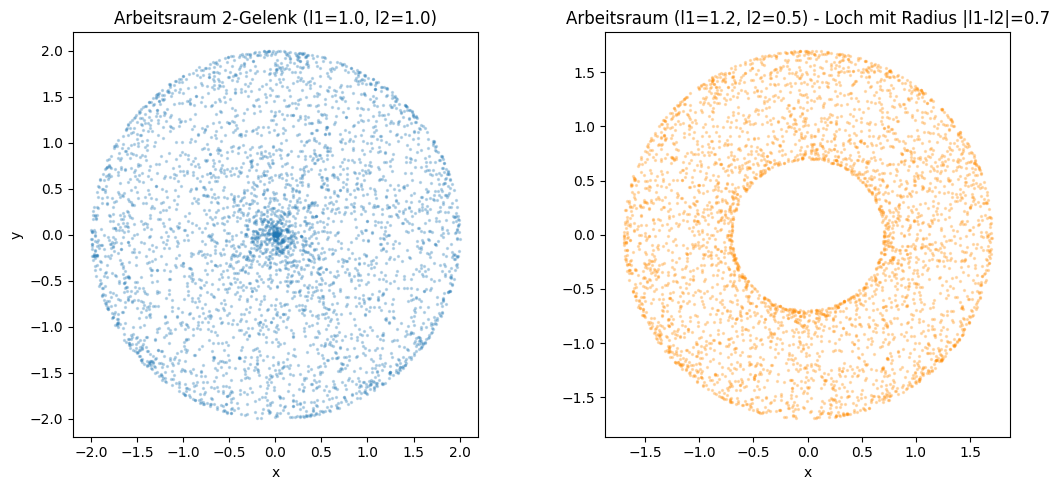

max. Reichweite gemessen: 1.700  (l1+l2 = 1.7)
min. Reichweite gemessen: 0.700  (|l1-l2| = 0.7)


In [4]:
Q = rng.uniform(-np.pi, np.pi, size=(4000, 2))
P = np.array([ee_position(q, L) for q in Q])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(P[:, 0], P[:, 1], s=2, alpha=0.25)
axes[0].set_title(f"Arbeitsraum 2-Gelenk (l1={L[0]}, l2={L[1]})")
axes[0].set_aspect("equal"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

# Ungleiche Laengen -> Kreisring mit Loch (Innenradius |l1-l2|)
L2 = [1.2, 0.5]
P2 = np.array([ee_position(q, L2) for q in Q])
axes[1].scatter(P2[:, 0], P2[:, 1], s=2, alpha=0.25, color="darkorange")
axes[1].set_title(f"Arbeitsraum (l1={L2[0]}, l2={L2[1]}) - Loch mit Radius |l1-l2|={abs(L2[0]-L2[1]):.1f}")
axes[1].set_aspect("equal"); axes[1].set_xlabel("x")
plt.tight_layout(); plt.show()

print(f"max. Reichweite gemessen: {np.linalg.norm(P2, axis=1).max():.3f}  (l1+l2 = {sum(L2)})")
print(f"min. Reichweite gemessen: {np.linalg.norm(P2, axis=1).min():.3f}  (|l1-l2| = {abs(L2[0]-L2[1])})")


**Erwartung.** Bei gleichen Laengen ($l_1=l_2$) ist der Arbeitsraum eine **volle Kreisscheibe**
vom Radius $l_1+l_2=2$ (der Innenradius $|l_1-l_2|=0$ verschwindet). Bei **ungleichen** Laengen
entsteht ein **Kreisring mit Loch**: Aussenradius $l_1+l_2=1.7$, Innenradius $|l_1-l_2|=0.7$ —
Punkte naeher als 0.7 an der Basis sind **unerreichbar**, egal wie man die Gelenke stellt.

## Teil D — Die Jacobi-Matrix und ihre Singularitaeten

Die Jacobi-Matrix ist die Ableitung der Vorwaertskinematik, $\dot{\mathbf x}=\mathbf J(\mathbf q)\dot{\mathbf q}$.
Fuer den planaren 2-Gelenk-Arm ergibt Ableiten der Formeln aus Teil B:

$$\mathbf J = \begin{pmatrix}
-l_1\sin q_1 - l_2\sin(q_1{+}q_2) & -l_2\sin(q_1{+}q_2)\\
\;\;\,l_1\cos q_1 + l_2\cos(q_1{+}q_2) & \;\;\,l_2\cos(q_1{+}q_2)\end{pmatrix}$$

**Deine Aufgabe:** Trage $\mathbf J$ ein. Danach vergleichen wir sie mit einer **numerischen**
Ableitung (zentraler Differenzenquotient) — der beste Test fuer jede analytische Ableitung.

In [5]:
def jacobian_analytic(q, lengths):
    # Analytische Jacobi-Matrix (2x2) fuer den planaren 2-Gelenk-Arm
    q1, q2 = q
    l1, l2 = lengths
    s1, c1 = np.sin(q1), np.cos(q1)
    s12, c12 = np.sin(q1+q2), np.cos(q1+q2)
    J = np.array([[-l1*s1 - l2*s12, -l2*s12],
                  [ l1*c1 + l2*c12,  l2*c12]])
    return J

def jacobian_numeric(q, lengths, h=1e-6):
    # Numerische Jacobi via zentralem Differenzenquotienten   [vorgegeben]
    q = np.asarray(q, float)
    cols = []
    for k in range(len(q)):
        e = np.zeros(len(q)); e[k] = h
        cols.append((ee_position(q+e, lengths) - ee_position(q-e, lengths)) / (2*h))
    return np.column_stack(cols)

q_test = np.array([0.7, 1.1])
Ja, Jn = jacobian_analytic(q_test, L), jacobian_numeric(q_test, L)
print("analytisch:\n", Ja)
print("numerisch :\n", Jn)
print("uebereinstimmend:", np.allclose(Ja, Jn, atol=1e-6))
print()
# Determinante und Singularitaeten
print(f"det J = {np.linalg.det(Ja):.6f}   l1*l2*sin(q2) = {L[0]*L[1]*np.sin(q_test[1]):.6f}")
for q2 in [0.0, np.pi]:
    print(f"  q2={q2:.3f} (gestreckt/eingeklappt): det J = "
          f"{np.linalg.det(jacobian_analytic([0.4, q2], L)):.2e}  -> SINGULAER")


analytisch:
 [[-1.6181 -0.9738]
 [ 0.5376 -0.2272]]
numerisch :
 [[-1.6181 -0.9738]
 [ 0.5376 -0.2272]]
uebereinstimmend: True

det J = 0.891207   l1*l2*sin(q2) = 0.891207
  q2=0.000 (gestreckt/eingeklappt): det J = 1.04e-17  -> SINGULAER
  q2=3.142 (gestreckt/eingeklappt): det J = 2.48e-16  -> SINGULAER


**Erwartung / Selbstcheck.**
- `uebereinstimmend: True` — analytische und numerische Ableitung sind identisch (bis ~$10^{-6}$).
- $\det\mathbf J$ stimmt exakt mit $l_1 l_2\sin q_2$ ueberein.
- Bei $q_2=0$ (**gestreckt**) und $q_2=\pi$ (**eingeklappt**) wird $\det\mathbf J=0$: **Singularitaet**.

**Was das physikalisch heisst:** Im gestreckten Zustand kann sich der Endeffektor **nicht weiter
radial nach aussen** bewegen — eine Bewegungsrichtung ist verloren. Naeher an der Singularitaet
braeuchte man immer groessere Gelenkgeschwindigkeiten fuer dieselbe Handbewegung. Genau das macht
die naive Pseudoinverse in der inversen Kinematik instabil (Thema von **P02**).

## Teil E — Manipulierbarkeit sichtbar machen

Die **Manipulierbarkeit** $w=\sqrt{\det(\mathbf J\mathbf J^\top)}$ (Yoshikawa) misst, wie „gut"
sich der Arm in einer Konfiguration bewegen laesst; sie faellt in Singularitaeten auf 0.
Wir zeichnen sie ueber den Konfigurationsraum $(q_1,q_2)$ — und ein paar Armposen dazu.
(Zellen vorgegeben.)

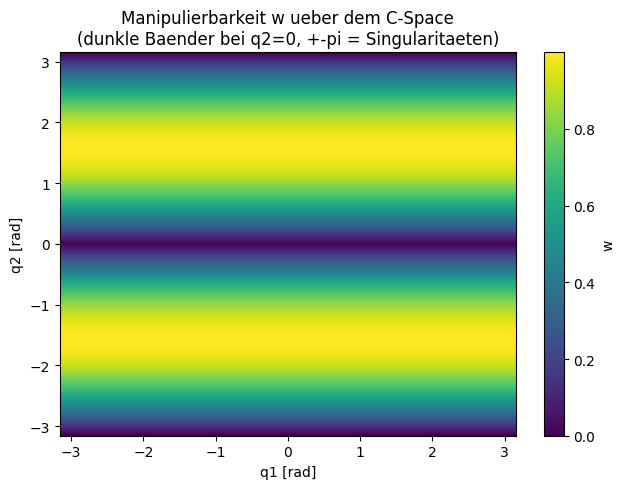

w haengt NUR von q2 ab (senkrechte Streifen) - konsistent mit det J = l1*l2*sin(q2).


In [6]:
q1s = np.linspace(-np.pi, np.pi, 200)
q2s = np.linspace(-np.pi, np.pi, 200)
W = np.zeros((len(q2s), len(q1s)))
for i, q2 in enumerate(q2s):
    for j, q1 in enumerate(q1s):
        J = jacobian_analytic([q1, q2], L)
        W[i, j] = np.sqrt(max(np.linalg.det(J @ J.T), 0.0))

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.pcolormesh(q1s, q2s, W, shading="auto", cmap="viridis")
ax.set_xlabel("q1 [rad]"); ax.set_ylabel("q2 [rad]")
ax.set_title("Manipulierbarkeit w ueber dem C-Space\n(dunkle Baender bei q2=0, +-pi = Singularitaeten)")
plt.colorbar(im, ax=ax, label="w"); plt.tight_layout(); plt.show()
print("w haengt NUR von q2 ab (senkrechte Streifen) - konsistent mit det J = l1*l2*sin(q2).")


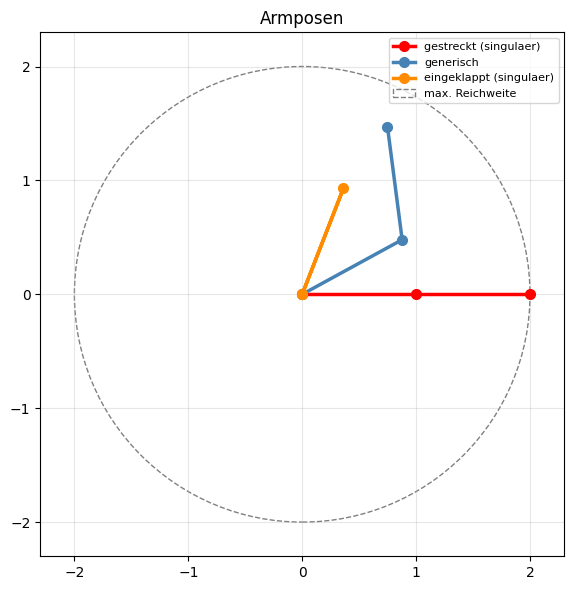

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
for q, col, lab in [([0.0, 0.0], "red", "gestreckt (singulaer)"),
                    ([0.5, 1.2], "steelblue", "generisch"),
                    ([1.2, np.pi], "darkorange", "eingeklappt (singulaer)")]:
    pts = fk_joints(np.array(q), L)
    ax.plot(pts[:, 0], pts[:, 1], "o-", color=col, lw=2.5, ms=7, label=lab)
circ = plt.Circle((0, 0), sum(L), fill=False, ls="--", color="gray", label="max. Reichweite")
ax.add_patch(circ)
ax.set_aspect("equal"); ax.set_xlim(-2.3, 2.3); ax.set_ylim(-2.3, 2.3)
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_title("Armposen")
plt.tight_layout(); plt.show()


## Fazit

Du hast die kinematische Grundlage gebaut:
- die **DH-Matrix** und die **Kette** (verifiziert gegen die geschlossene Formel),
- den **Arbeitsraum** (Kreisring — mit Loch bei ungleichen Gliedlaengen),
- die **Jacobi-Matrix** (analytisch, numerisch gegengeprueft) und ihre **Singularitaeten**
  bei $q_2 = 0, \pi$.

Damit ist alles bereit fuer die Umkehrung: **P02 (medium)** loest die **inverse Kinematik** —
analytisch (mit beiden Ellbogen-Loesungen) und numerisch ueber die Jacobi-Matrix. Dort wirst du
sehen, warum die Singularitaeten aus Teil D die naive Pseudoinverse sprengen und wie
**Damped Least Squares** das rettet.